In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=sns.load_dataset(name='car_crashes')
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [30]:
from turtle import color

<Axes: xlabel='alcohol', ylabel='total'>

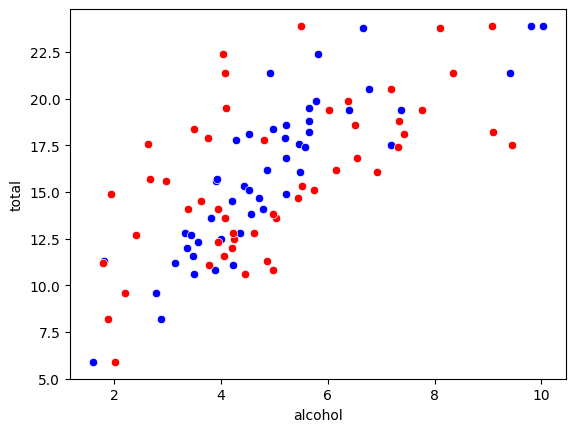

In [ ]:
from turtle import color
sns.scatterplot(x='alcohol',y='total',color="blue",data=df)
sns.scatterplot(x='speeding',y='total',color="red",data=df)

In [32]:
#cdeclaro las variales dependientes e independientes
vars_Indep=df[['alcohol']]#puede ser una o muchas
var_Dep=df['total']#solo puede ser una

In [33]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [ ]:
type(model)

sklearn.linear_model._base.LinearRegression

In [ ]:
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [36]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['alcohol'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.0325063]),
 'rank_': 1,
 'singular_': array([12.22681605]),
 'intercept_': np.float64(5.857776154826299)}

In [37]:
y_pred=model.predict(X=df[['alcohol']])
y_pred

array([17.32111171, 15.05486718, 16.44306899, 17.69509287, 12.68699734,
       13.59756016, 13.76016066, 15.73575679,  9.0955587 , 16.40851638,
       13.78455074, 20.44100889, 14.87600663, 14.70324359, 14.40446516,
       13.8353634 , 14.54064309, 15.86177218, 19.6076813 , 15.06502971,
       13.98780137, 11.69106925, 13.88211104, 11.5162737 , 16.94713055,
       16.98371566, 24.99585551, 16.45729653, 15.41868581, 12.93089809,
       12.23171592, 15.95526747, 13.10772614, 16.44306899, 26.26007443,
       15.60161138, 17.58737003, 12.62195713, 17.32517672, 14.43088774,
       25.77430543, 18.86988151, 17.3515993 , 20.84141263,  9.53254755,
       14.15040187, 12.82724027, 12.96748321, 19.40239816, 15.11380986,
       17.17477126])

In [ ]:
df.insert(0,'predicciones',y_pred)
df

<Axes: xlabel='alcohol', ylabel='total'>

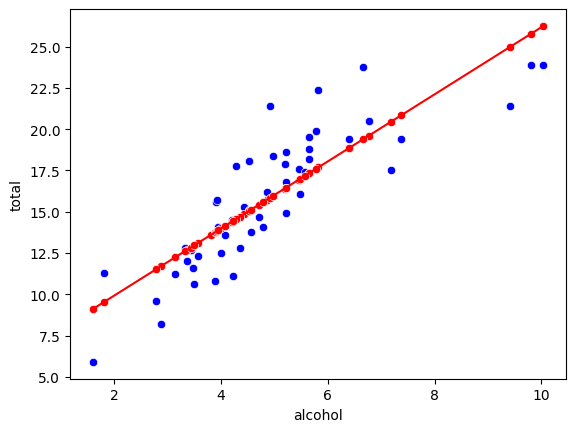

In [39]:
sns.scatterplot(x='alcohol',y='total',color="blue",data=df)
sns.scatterplot(x='alcohol',y='predicciones',color="red",data=df)
sns.lineplot(x='alcohol',y='predicciones',color="red",data=df)

In [40]:
coef_Deter=model.score(X=vars_Indep, y=var_Dep)
coef_Deter


0.7269492966665405

In [45]:
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8526132163334911)

In [47]:
df=df.drop(['abbrev'],axis=1)

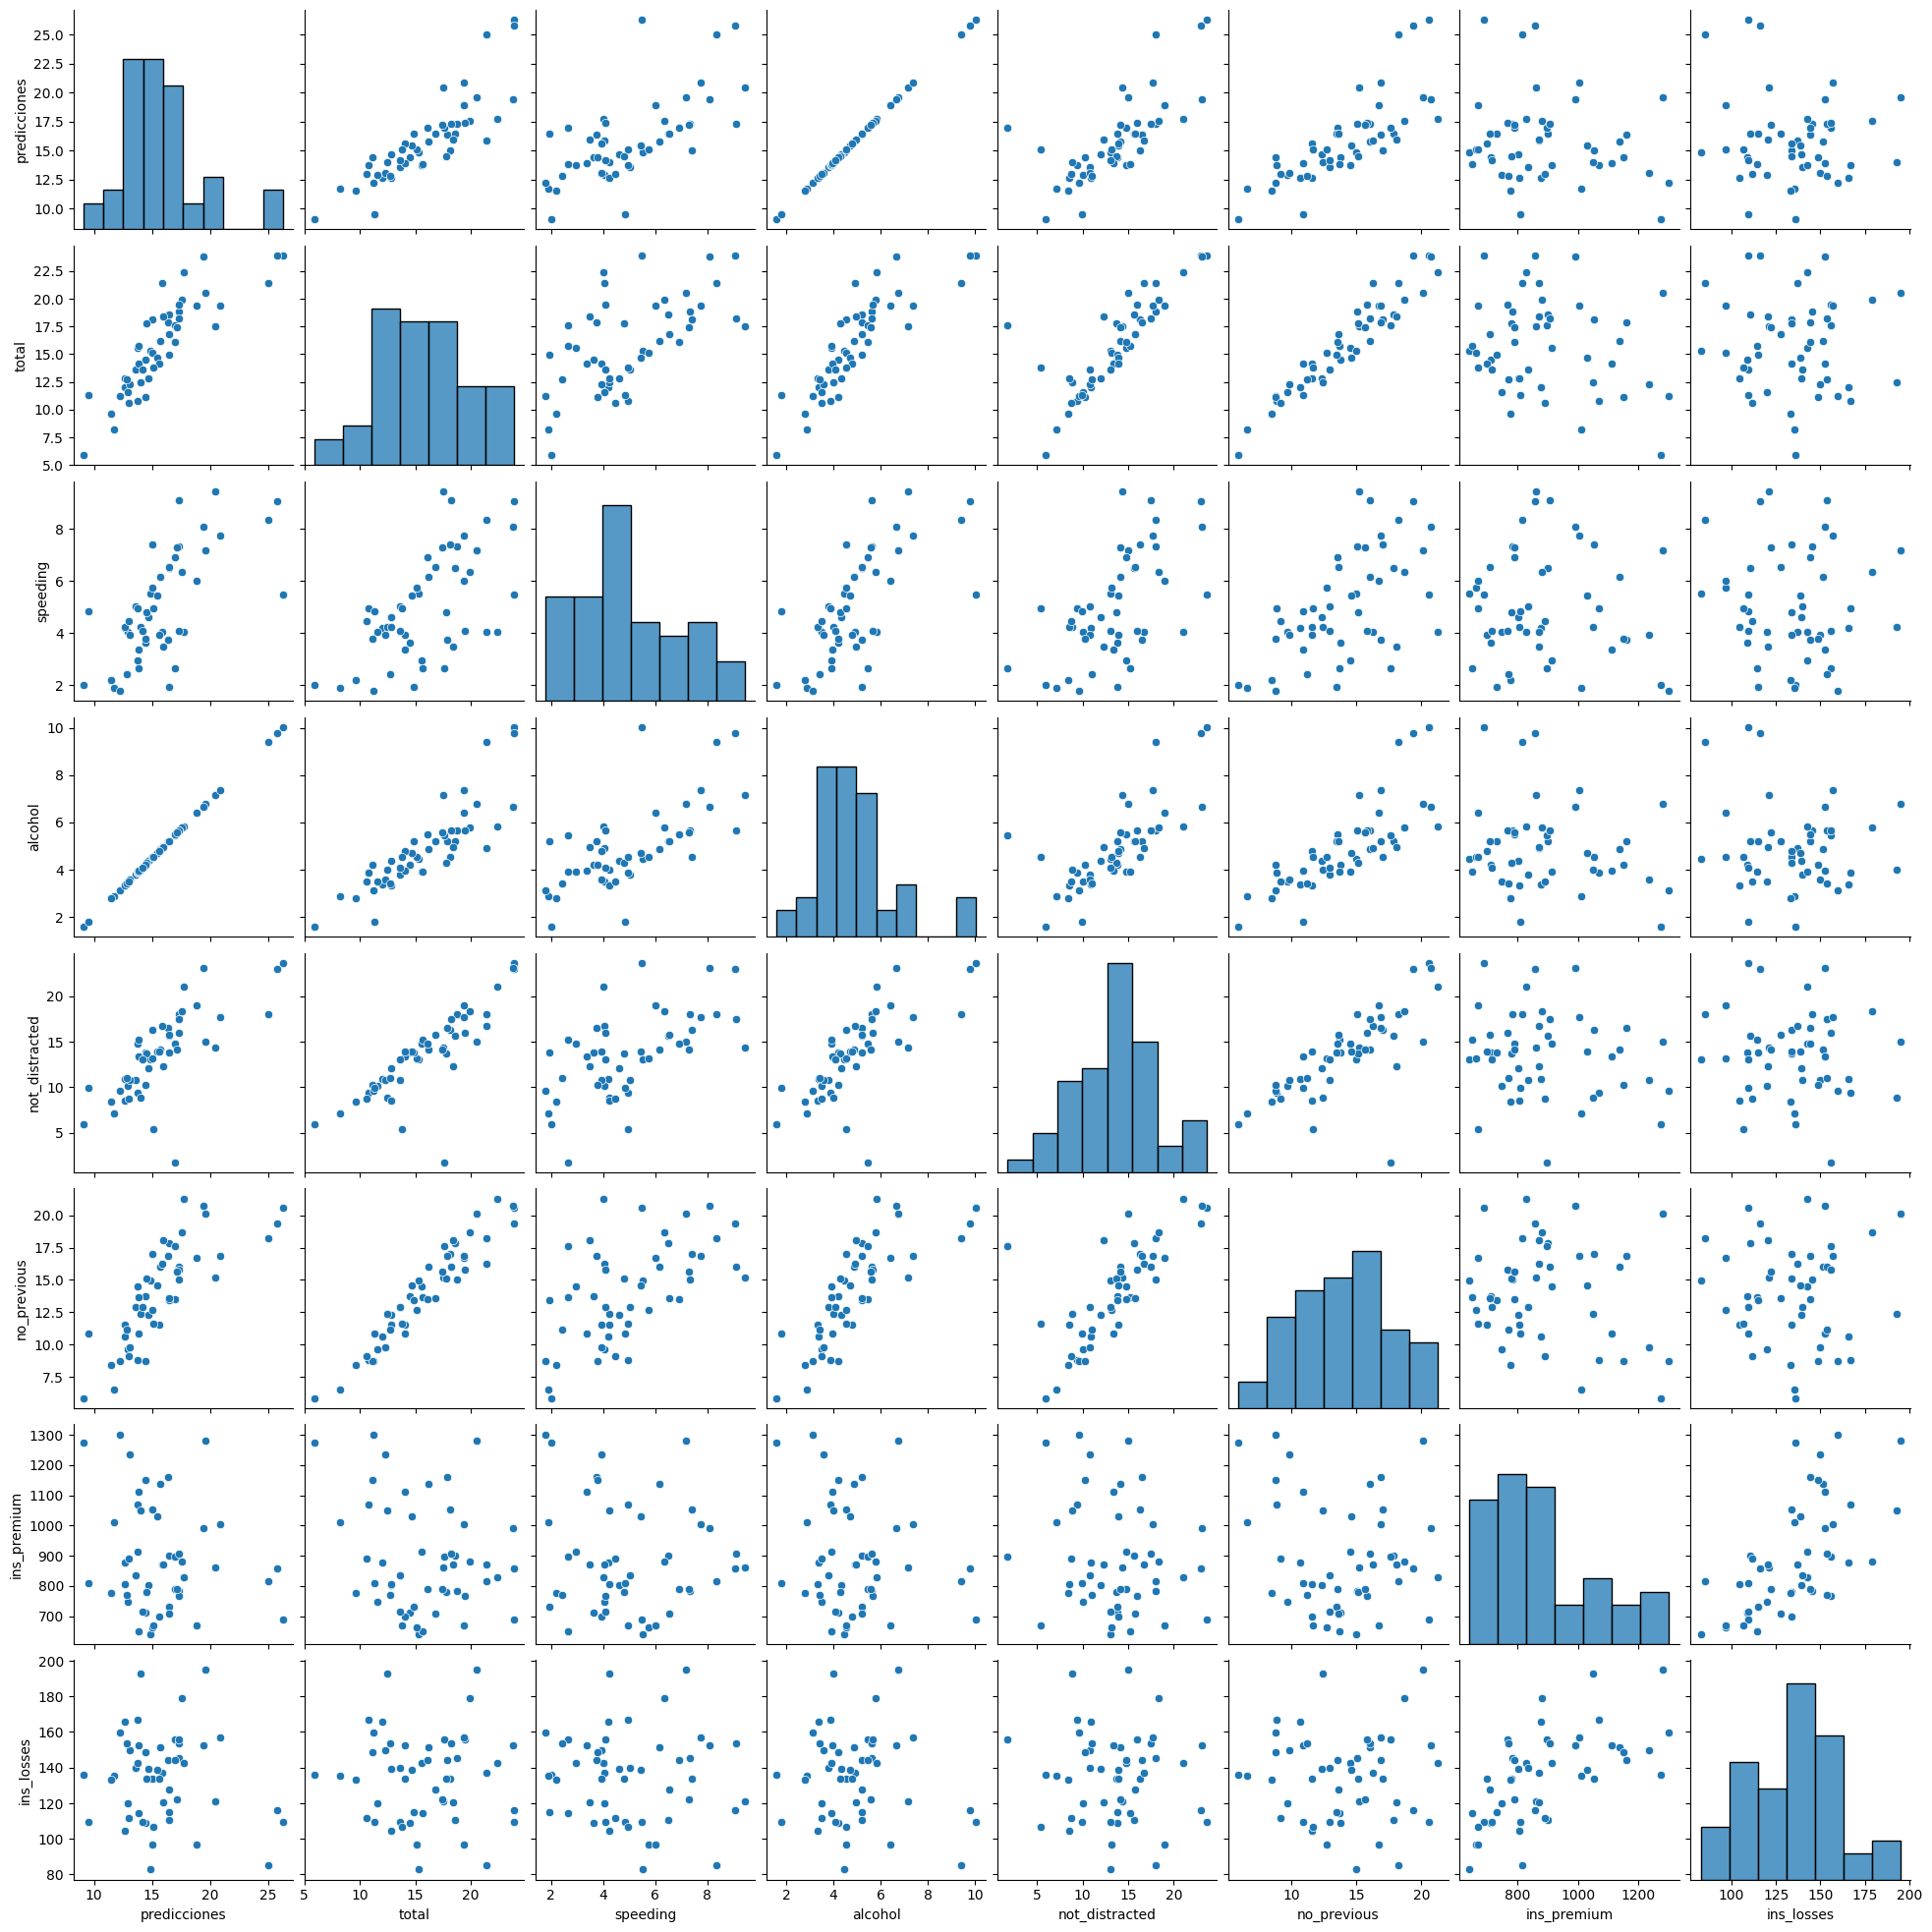

In [42]:
sns.pairplot(df)

In [48]:
Corr_Factors=df.corr()
Corr_Factors

,predicciones,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
predicciones,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
total,0.852613,1.000000,0.611548,0.852613,0.827560,0.956179,-0.199702,-0.036011
speeding,0.669719,0.611548,1.000000,0.669719,0.588010,0.571976,-0.077675,-0.065928
alcohol,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
not_distracted,0.732816,0.827560,0.588010,0.732816,1.000000,0.747307,-0.174856,-0.075970
no_previous,0.783520,0.956179,0.571976,0.783520,0.747307,1.000000,-0.156895,-0.006359
ins_premium,-0.170612,-0.199702,-0.077675,-0.170612,-0.174856,-0.156895,1.000000,0.623116
ins_losses,-0.112547,-0.036011,-0.065928,-0.112547,-0.075970,-0.006359,0.623116,1.000000


In [49]:
Corr_Factors1=abs(Corr_Factors)
Corr_Factors1

,predicciones,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
predicciones,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,0.170612,0.112547
total,0.852613,1.000000,0.611548,0.852613,0.827560,0.956179,0.199702,0.036011
speeding,0.669719,0.611548,1.000000,0.669719,0.588010,0.571976,0.077675,0.065928
alcohol,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,0.170612,0.112547
not_distracted,0.732816,0.827560,0.588010,0.732816,1.000000,0.747307,0.174856,0.075970
no_previous,0.783520,0.956179,0.571976,0.783520,0.747307,1.000000,0.156895,0.006359
ins_premium,0.170612,0.199702,0.077675,0.170612,0.174856,0.156895,1.000000,0.623116
ins_losses,0.112547,0.036011,0.065928,0.112547,0.075970,0.006359,0.623116,1.000000


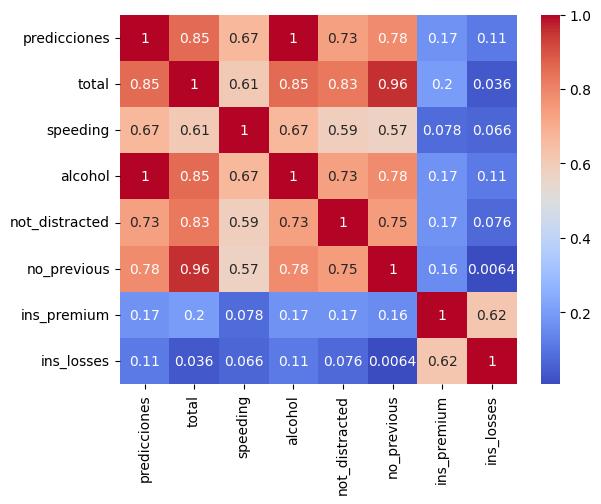

In [50]:
Heat_map=sns.heatmap(data=Corr_Factors1,cmap='coolwarm',annot=True)

<Axes: >

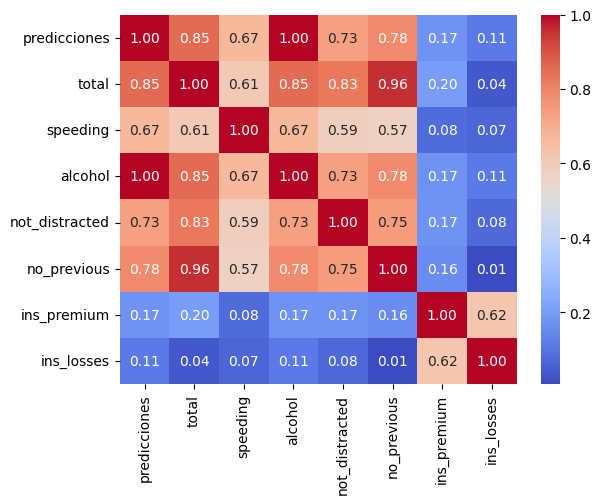

In [53]:
Heat_map=sns.heatmap(Corr_Factors1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map